Check whether a CUDA-capable GPU is available. Training the CNN runs much faster on GPU than CPU, but the code falls back to CPU if no GPU is detected.

In [10]:
import torch
print("CUDA beschikbaar:", torch.cuda.is_available())
print("Device:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU")

CUDA beschikbaar: True
Device: Tesla T4


Set random seeds for Python, NumPy, and PyTorch (including CUDA) so every run produces the same model weights and metrics.

In [11]:
import random
import numpy as np

def set_seed(seed=42):
    """Zorg voor reproduceerbare resultaten."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    # Voor strikt deterministisch gedrag op CUDA:
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

Import the core libraries used throughout the notebook: PyTorch for the model, pandas/NumPy for data handling, and scikit-learn for evaluation metrics.

In [12]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix, classification_report

Download the BBBP dataset from DeepChem. Each row contains a SMILES string and a binary label p_np (1 = the molecule crosses the blood-brain barrier, 0 = it does not), with a clear class imbalance of roughly 76% positive vs. 24% negative.

In [13]:
URL = "https://deepchemdata.s3-us-west-1.amazonaws.com/datasets/BBBP.csv"
df = pd.read_csv(URL)
df = df.dropna(subset=["smiles"]).reset_index(drop=True)

print(f"Aantal moleculen: {len(df)}")
print(f"Class balance:\n{df['p_np'].value_counts()}")

Aantal moleculen: 2050
Class balance:
p_np
1    1567
0     483
Name: count, dtype: int64


Install RDKit and split the data using scaffold splitting: molecules sharing the same Bemis-Murcko scaffold (their core ring system) are kept together in the same set. This prevents the test set from containing molecules nearly identical to those in training, giving a more honest estimate of how the model generalizes to genuinely new compounds.

In [14]:
!pip install rdkit
from rdkit import Chem
from rdkit.Chem.Scaffolds import MurckoScaffold
from collections import defaultdict
from sklearn.model_selection import GroupKFold

def get_scaffold(smi):
    """Bereken Bemis-Murcko scaffold van een SMILES-string."""
    mol = Chem.MolFromSmiles(smi)
    if mol is None:
        return ""
    scaffold_mol = MurckoScaffold.GetScaffoldForMol(mol)
    return Chem.MolToSmiles(scaffold_mol)

smiles = df["smiles"].tolist()
labels = df["p_np"].astype(int).tolist()

# --- Bereken scaffolds voor alle moleculen ---
print("Berekenen scaffolds...")
scaffolds = [get_scaffold(s) for s in smiles]
print(f"Unieke scaffolds: {len(set(scaffolds))} (uit {len(smiles)} moleculen)")

# Groepeer molecule-indices per scaffold
scaffold_to_indices = defaultdict(list)
for i, sc in enumerate(scaffolds):
    scaffold_to_indices[sc].append(i)

# Sorteer scaffold-groepen van groot naar klein
scaffold_groups = sorted(scaffold_to_indices.values(), key=lambda g: -len(g))

# --- Verdeel scaffolds over train+val en test, met class-balance-bewaking ---
n_total = len(smiles)
test_size_target = int(0.10 * n_total)
overall_pos_rate = np.mean(labels)   # ~0.76 voor BBBP

trainval_idx, test_idx = [], []
trainval_labels_so_far = []
test_labels_so_far     = []

for group in scaffold_groups:
    group_labels = [labels[i] for i in group]

    if len(test_idx) < test_size_target:
        # Kijk of test deze groep aankan zonder de balans te veel te verstoren
        candidate_test = test_labels_so_far + group_labels
        test_pos_rate = np.mean(candidate_test)

        if (abs(test_pos_rate - overall_pos_rate) < 0.10
                or len(test_idx) < 0.5 * test_size_target):
            test_idx.extend(group)
            test_labels_so_far.extend(group_labels)
            continue

    trainval_idx.extend(group)
    trainval_labels_so_far.extend(group_labels)

# --- Maak de bijbehorende lijsten ---
trainval_smiles    = [smiles[i]    for i in trainval_idx]
trainval_labels    = [labels[i]    for i in trainval_idx]
trainval_scaffolds = [scaffolds[i] for i in trainval_idx]  # nodig voor CV
test_smiles        = [smiles[i]    for i in test_idx]
test_labels        = [labels[i]    for i in test_idx]

# --- Rapporteer ---
print(f"\nTrain+Val: {len(trainval_smiles)} | Test: {len(test_smiles)}")
print(f"Class balance train+val: {np.bincount(trainval_labels)} "
      f"(pos rate: {np.mean(trainval_labels):.3f})")
print(f"Class balance test:      {np.bincount(test_labels)} "
      f"(pos rate: {np.mean(test_labels):.3f})")
print(f"Overall pos rate:        {overall_pos_rate:.3f}")

# --- Sanity check op scaffold-disjunctie ---
trainval_scaffold_set = set(trainval_scaffolds)
test_scaffold_set     = {scaffolds[i] for i in test_idx}
overlap = trainval_scaffold_set & test_scaffold_set
print(f"\nScaffold overlap train+val ↔ test: {len(overlap)} "
      f"(zou 0 moeten zijn)")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.1/37.1 MB 62.7 MB/s eta 0:00:00
Berekenen scaffolds...


[12:53:38] Explicit valence for atom # 1 N, 4, is greater than permitted
[12:53:38] WARNING: not removing hydrogen atom without neighbors
[12:53:38] Explicit valence for atom # 6 N, 4, is greater than permitted
[12:53:38] WARNING: not removing hydrogen atom without neighbors
[12:53:38] WARNING: not removing hydrogen atom without neighbors
[12:53:38] WARNING: not removing hydrogen atom without neighbors
[12:53:38] WARNING: not removing hydrogen atom without neighbors
[12:53:38] WARNING: not removing hydrogen atom without neighbors
[12:53:38] WARNING: not removing hydrogen atom without neighbors
[12:53:38] Explicit valence for atom # 6 N, 4, is greater than permitted
[12:53:38] WARNING: not removing hydrogen atom without neighbors
[12:53:38] WARNING: not removing hydrogen atom without neighbors
[12:53:38] WARNING: not removing hydrogen atom without neighbors
[12:53:38] WARNING: not removing hydrogen atom without neighbors
[12:53:38] Explicit valence for atom # 11 N, 4, is greater than pe

Unieke scaffolds: 1102 (uit 2050 moleculen)

Train+Val: 1803 | Test: 247
Class balance train+val: [ 435 1368] (pos rate: 0.759)
Class balance test:      [ 48 199] (pos rate: 0.806)
Overall pos rate:        0.764

Scaffold overlap train+val ↔ test: 0 (zou 0 moeten zijn)


[12:53:39] WARNING: not removing hydrogen atom without neighbors
[12:53:39] WARNING: not removing hydrogen atom without neighbors
[12:53:39] WARNING: not removing hydrogen atom without neighbors
[12:53:39] WARNING: not removing hydrogen atom without neighbors
[12:53:39] WARNING: not removing hydrogen atom without neighbors
[12:53:39] WARNING: not removing hydrogen atom without neighbors
[12:53:39] WARNING: not removing hydrogen atom without neighbors
[12:53:39] WARNING: not removing hydrogen atom without neighbors
[12:53:39] WARNING: not removing hydrogen atom without neighbors
[12:53:39] WARNING: not removing hydrogen atom without neighbors
[12:53:39] WARNING: not removing hydrogen atom without neighbors
[12:53:39] WARNING: not removing hydrogen atom without neighbors


Build a character-level vocabulary from the training SMILES. Each unique character gets an integer index, plus two special tokens: <PAD> for padding shorter strings and <UNK> for any characters not seen during training.

In [15]:
all_chars = set()
for smi in trainval_smiles:   # was: train_smiles
    all_chars.update(smi)

sorted_chars = sorted(all_chars)
char_to_idx = {"<PAD>": 0, "<UNK>": 1}
for i, c in enumerate(sorted_chars, start=2):
    char_to_idx[c] = i

idx_to_char = {i: c for c, i in char_to_idx.items()}
vocab_size = len(char_to_idx)
print(f"Vocab size: {vocab_size}")

Vocab size: 41


Inspect the length distribution of the training SMILES. The 95th percentile confirms that capping sequences at 200 characters covers nearly all molecules without significant truncation.

In [16]:
lengths = [len(s) for s in trainval_smiles]   # was: train_smiles
print(f"SMILES lengtes — min: {min(lengths)}, max: {max(lengths)}, "
      f"mean: {np.mean(lengths):.1f}, 95-percentiel: {int(np.percentile(lengths, 95))}")

SMILES lengtes — min: 5, max: 400, mean: 55.1, 95-percentiel: 108


Define the PyTorch Dataset class that converts each SMILES string into a fixed-length integer sequence — shorter strings are padded, longer ones are truncated at 200 characters.

In [17]:
MAX_LENGTH = 200

def encode_smiles(smi, char_to_idx, max_length=MAX_LENGTH):
    """Zet een SMILES-string om in een lijst integers van vaste lengte."""
    smi = smi[:max_length]
    ids = [char_to_idx.get(c, char_to_idx["<UNK>"]) for c in smi]
    ids = ids + [char_to_idx["<PAD>"]] * (max_length - len(ids))
    return ids


class SMILES_CNN_Dataset(Dataset):
    def __init__(self, smiles, labels, char_to_idx, max_length=MAX_LENGTH):
        self.smiles = smiles
        self.labels = labels
        self.char_to_idx = char_to_idx
        self.max_length = max_length

    def __len__(self):
        return len(self.smiles)

    def __getitem__(self, idx):
        ids = encode_smiles(self.smiles[idx], self.char_to_idx, self.max_length)
        return {
            "input_ids": torch.tensor(ids, dtype=torch.long),
            "labels": torch.tensor(self.labels[idx], dtype=torch.long),
        }

print(f"Dataset-klasse gedefinieerd. MAX_LENGTH = {MAX_LENGTH}")

Dataset-klasse gedefinieerd. MAX_LENGTH = 200


Define the SMILES-CNN model: an embedding layer maps characters to 128-dimensional vectors, three parallel 1D convolutions with kernel sizes 3, 5, and 7 capture chemical motifs of different lengths, global max-pooling extracts the strongest signal per filter, and a linear layer produces 2 class scores. Optional class weights let the cross-entropy loss compensate for the class imbalance.

In [18]:
class SMILES_CNN(nn.Module):
    def __init__(self, vocab_size, embed_dim=128, num_filters=64,
                 kernel_sizes=(3, 5, 7), dropout=0.5, num_classes=2,
                 class_weights=None):
        super().__init__()

        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.convs = nn.ModuleList([
            nn.Conv1d(embed_dim, num_filters, kernel_size=k, padding=k // 2)
            for k in kernel_sizes
        ])
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(num_filters * len(kernel_sizes), num_classes)

        if class_weights is not None:
            self.register_buffer(
                "class_weights",
                torch.tensor(class_weights, dtype=torch.float32)
            )
        else:
            self.class_weights = None

    def forward(self, input_ids, labels=None):
        x = self.embedding(input_ids)
        x = x.permute(0, 2, 1)

        conv_outputs = []
        for conv in self.convs:
            c = F.relu(conv(x))
            p = F.max_pool1d(c, c.size(2)).squeeze(2)
            conv_outputs.append(p)

        x = torch.cat(conv_outputs, dim=1)
        x = self.dropout(x)
        logits = self.fc(x)

        loss = None
        if labels is not None:
            loss = F.cross_entropy(logits, labels, weight=self.class_weights)

        return {"loss": loss, "logits": logits}


# Deze regels staan BUITEN de class — geen inspringing
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

Device: cuda


Define train_model and evaluate. The training function runs Adam optimization and keeps the model state from the epoch with the best validation ROC-AUC; evaluate returns loss, accuracy, and ROC-AUC on any given data loader.

In [19]:
from torch.utils.data import DataLoader

BATCH_SIZE = 32

def evaluate(model, loader, device):
    """Evalueer model op een loader, geeft loss/accuracy/AUC terug."""
    model.eval()
    total_loss = 0.0
    all_logits, all_labels = [], []

    with torch.no_grad():
        for batch in loader:
            input_ids = batch["input_ids"].to(device)
            labels = batch["labels"].to(device)
            out = model(input_ids, labels=labels)
            total_loss += out["loss"].item() * input_ids.size(0)
            all_logits.append(out["logits"].cpu())
            all_labels.append(labels.cpu())

    logits = torch.cat(all_logits)
    labels = torch.cat(all_labels).numpy()
    preds = logits.argmax(dim=1).numpy()
    probs = torch.softmax(logits, dim=1)[:, 1].numpy()

    return {
        "loss": total_loss / len(loader.dataset),
        "accuracy": accuracy_score(labels, preds),
        "roc_auc":  roc_auc_score(labels, probs),
    }


def train_model(model, train_loader, val_loader, epochs=30, lr=1e-3,
                weight_decay=1e-4, verbose=True):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)

    best_val_auc = 0.0
    best_state = None
    history = []

    if verbose:
        print(f"{'Epoch':>5} | {'Train Loss':>10} | {'Val Loss':>9} | {'Val Acc':>7} | {'Val AUC':>7}")
        print("-" * 55)

    for epoch in range(1, epochs + 1):
        model.train()
        epoch_loss = 0.0
        for batch in train_loader:
            input_ids = batch["input_ids"].to(device)
            labels = batch["labels"].to(device)

            optimizer.zero_grad()
            out = model(input_ids, labels=labels)
            out["loss"].backward()
            optimizer.step()
            epoch_loss += out["loss"].item() * input_ids.size(0)

        train_loss = epoch_loss / len(train_loader.dataset)
        val_metrics = evaluate(model, val_loader, device)
        history.append({"epoch": epoch, "train_loss": train_loss, **val_metrics})

        if verbose:
            print(f"{epoch:>5} | {train_loss:>10.4f} | {val_metrics['loss']:>9.4f} "
                  f"| {val_metrics['accuracy']:>7.4f} | {val_metrics['roc_auc']:>7.4f}")

        if val_metrics["roc_auc"] > best_val_auc:
            best_val_auc = val_metrics["roc_auc"]
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}

    model.load_state_dict(best_state)
    if verbose:
        print(f"\nBeste val AUC: {best_val_auc:.4f}")
    return history

print("Functies 'evaluate' en 'train_model' gedefinieerd.")

Functies 'evaluate' en 'train_model' gedefinieerd.


Run a hyperparameter grid search over learning rate, dropout, and number of filters using 5-fold scaffold-based cross-validation. The configuration with the highest mean validation ROC-AUC is selected, and the 5 trained fold-models are kept for ensembling later.

In [20]:
from sklearn.model_selection import GroupKFold
from sklearn.utils.class_weight import compute_class_weight
from itertools import product
import time

N_FOLDS = 5
EPOCHS = 30
BATCH_SIZE = 32

# ----------------------------
# Hyperparameter grid
# ----------------------------
param_grid = {
    "lr":          [1e-4, 1e-3, 1e-2],
    "dropout":     [0.3, 0.5],
    "num_filters": [32, 64],
}

keys = list(param_grid.keys())
combos = [dict(zip(keys, values)) for values in product(*param_grid.values())]
print(f"Aantal combinaties: {len(combos)}")
print(f"Verwachte trainruns: {len(combos) * N_FOLDS}\n")

trainval_smiles_arr = np.array(trainval_smiles)
trainval_labels_arr = np.array(trainval_labels)

# ----------------------------
# CV-runner voor één combinatie
# ----------------------------
def run_cv_for_combo(hyperparams):
    """Run 5-fold scaffold CV met gegeven hyperparams (silent)."""
    gkf = GroupKFold(n_splits=N_FOLDS)
    val_aucs, models = [], []
    val_probs_all, val_labels_all = [], []

    for fold, (train_idx, val_idx) in enumerate(
        gkf.split(trainval_smiles_arr, trainval_labels_arr, groups=trainval_scaffolds),
        start=1
    ):
        fold_train_smiles = trainval_smiles_arr[train_idx].tolist()
        fold_train_labels = trainval_labels_arr[train_idx].tolist()
        fold_val_smiles   = trainval_smiles_arr[val_idx].tolist()
        fold_val_labels   = trainval_labels_arr[val_idx].tolist()

        cw = compute_class_weight(
            "balanced", classes=np.array([0, 1]),
            y=np.array(fold_train_labels)
        )

        train_ds = SMILES_CNN_Dataset(fold_train_smiles, fold_train_labels, char_to_idx)
        val_ds   = SMILES_CNN_Dataset(fold_val_smiles,   fold_val_labels,   char_to_idx)
        train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
        val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False)

        model = SMILES_CNN(
            vocab_size=vocab_size,
            num_filters=hyperparams["num_filters"],
            dropout=hyperparams["dropout"],
            class_weights=cw
        ).to(device)

        history = train_model(
            model, train_loader, val_loader,
            epochs=EPOCHS, lr=hyperparams["lr"], verbose=False
        )

        best_val = max(history, key=lambda h: h["roc_auc"])
        val_aucs.append(best_val["roc_auc"])
        models.append(model)

        # OOF predictions verzamelen
        model.eval()
        probs, lbls = [], []
        with torch.no_grad():
            for batch in val_loader:
                out = model(batch["input_ids"].to(device))
                probs.append(torch.softmax(out["logits"], dim=1)[:, 1].cpu().numpy())
                lbls.append(batch["labels"].numpy())
        val_probs_all.append(np.concatenate(probs))
        val_labels_all.append(np.concatenate(lbls))

    return np.mean(val_aucs), np.std(val_aucs), models, val_probs_all, val_labels_all

# ----------------------------
# Grid search loop
# ----------------------------
set_seed(42)
results = []
start_time = time.time()

for i, combo in enumerate(combos, start=1):
    print(f"[{i:2d}/{len(combos)}] {combo}", end="  → ")
    t0 = time.time()
    mean_auc, std_auc, models, val_probs, val_labels = run_cv_for_combo(combo)
    elapsed = time.time() - t0
    print(f"Val AUC = {mean_auc:.4f} ± {std_auc:.4f}  ({elapsed:.1f}s)")
    results.append({
        "hyperparams": combo,
        "mean_auc":    mean_auc,
        "std_auc":     std_auc,
        "models":      models,
        "val_probs":   val_probs,
        "val_labels":  val_labels,
    })

total = time.time() - start_time
print(f"\nTotale tijd grid search: {total/60:.1f} min")

# ----------------------------
# Top 5 overzicht
# ----------------------------
results_sorted = sorted(results, key=lambda r: -r["mean_auc"])

print("\n========== TOP 5 HYPERPARAMETER COMBINATIES ==========")
print(f"{'Rank':>4} | {'Mean AUC':>10} | {'Std':>7} | Hyperparams")
print("-" * 75)
for rank, r in enumerate(results_sorted[:5], start=1):
    print(f"{rank:>4} | {r['mean_auc']:>10.4f} | {r['std_auc']:>7.4f} | {r['hyperparams']}")

# ----------------------------
# Beste combinatie selecteren voor Cell 11
# ----------------------------
best = results_sorted[0]
print(f"\n>>> Beste hyperparameters: {best['hyperparams']}")
print(f">>> Mean val ROC-AUC: {best['mean_auc']:.4f} ± {best['std_auc']:.4f}")

# Variabelen die Cell 11 verwacht
fold_models    = best["models"]
all_val_probs  = best["val_probs"]
all_val_labels = best["val_labels"]

Aantal combinaties: 12
Verwachte trainruns: 60

[ 1/12] {'lr': 0.0001, 'dropout': 0.3, 'num_filters': 32}  → Val AUC = 0.9413 ± 0.0191  (57.2s)
[ 2/12] {'lr': 0.0001, 'dropout': 0.3, 'num_filters': 64}  → Val AUC = 0.9464 ± 0.0165  (41.3s)
[ 3/12] {'lr': 0.0001, 'dropout': 0.5, 'num_filters': 32}  → Val AUC = 0.9417 ± 0.0183  (39.9s)
[ 4/12] {'lr': 0.0001, 'dropout': 0.5, 'num_filters': 64}  → Val AUC = 0.9459 ± 0.0166  (41.7s)
[ 5/12] {'lr': 0.001, 'dropout': 0.3, 'num_filters': 32}  → Val AUC = 0.9519 ± 0.0141  (40.5s)
[ 6/12] {'lr': 0.001, 'dropout': 0.3, 'num_filters': 64}  → Val AUC = 0.9525 ± 0.0136  (41.3s)
[ 7/12] {'lr': 0.001, 'dropout': 0.5, 'num_filters': 32}  → Val AUC = 0.9517 ± 0.0192  (40.0s)
[ 8/12] {'lr': 0.001, 'dropout': 0.5, 'num_filters': 64}  → Val AUC = 0.9511 ± 0.0162  (42.4s)
[ 9/12] {'lr': 0.01, 'dropout': 0.3, 'num_filters': 32}  → Val AUC = 0.9488 ± 0.0137  (40.0s)
[10/12] {'lr': 0.01, 'dropout': 0.3, 'num_filters': 64}  → Val AUC = 0.9499 ± 0.0115  (42.0s)


Tune the decision threshold on out-of-fold validation predictions to maximize macro F1 — doing this on validation rather than test avoids cherry-picking. Then average predictions across the 5 fold models on the test set and report metrics at both the default (0.5) and tuned thresholds.

In [21]:
from sklearn.metrics import (
    accuracy_score, roc_auc_score, confusion_matrix,
    classification_report, f1_score, average_precision_score
)

# === Stap 1: vind optimale threshold op out-of-fold val data ===
# Belangrijk: NIET op test set zoeken — anders is het cherry-picking
oof_probs  = np.concatenate(all_val_probs)
oof_labels = np.concatenate(all_val_labels)

thresholds = np.linspace(0.05, 0.95, 91)
val_f1s = [f1_score(oof_labels, (oof_probs > t).astype(int), average="macro")
           for t in thresholds]
best_t = thresholds[int(np.argmax(val_f1s))]
print(f"Optimale threshold (op out-of-fold val): {best_t:.3f}")
print(f"Macro F1 op val bij deze threshold:      {max(val_f1s):.4f}")

# === Stap 2: ensemble-voorspelling op test set ===
test_ds = SMILES_CNN_Dataset(test_smiles, test_labels, char_to_idx)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)

all_probs_per_fold = []
for m in fold_models:
    m.eval()
    probs = []
    with torch.no_grad():
        for batch in test_loader:
            out = m(batch["input_ids"].to(device))
            probs.append(torch.softmax(out["logits"], dim=1)[:, 1].cpu().numpy())
    all_probs_per_fold.append(np.concatenate(probs))

mean_probs = np.mean(all_probs_per_fold, axis=0)
y_true = np.array(test_labels)

# === Stap 3: rapporteer met DEFAULT threshold (0.5) ===
y_pred_default = (mean_probs > 0.5).astype(int)
print("\n=== Test resultaten — default threshold (0.5) ===")
print(f"Accuracy: {accuracy_score(y_true, y_pred_default):.4f}")
print(f"ROC-AUC:  {roc_auc_score(y_true, mean_probs):.4f}")
print(f"PR-AUC:   {average_precision_score(y_true, mean_probs):.4f}")
print(f"\nConfusion matrix:\n{confusion_matrix(y_true, y_pred_default)}")
print(f"\n{classification_report(y_true, y_pred_default, target_names=['geen BBB', 'wel BBB'])}")

# === Stap 4: rapporteer met TUNED threshold ===
y_pred_tuned = (mean_probs > best_t).astype(int)
print(f"\n=== Test resultaten — tuned threshold ({best_t:.3f}) ===")
print(f"Accuracy: {accuracy_score(y_true, y_pred_tuned):.4f}")
print(f"ROC-AUC:  {roc_auc_score(y_true, mean_probs):.4f}  (threshold-onafhankelijk)")
print(f"PR-AUC:   {average_precision_score(y_true, mean_probs):.4f}  (threshold-onafhankelijk)")
print(f"\nConfusion matrix:\n{confusion_matrix(y_true, y_pred_tuned)}")
print(f"\n{classification_report(y_true, y_pred_tuned, target_names=['geen BBB', 'wel BBB'])}")

Optimale threshold (op out-of-fold val): 0.340
Macro F1 op val bij deze threshold:      0.8507

=== Test resultaten — default threshold (0.5) ===
Accuracy: 0.8097
ROC-AUC:  0.9447
PR-AUC:   0.9869

Confusion matrix:
[[ 48   0]
 [ 47 152]]

              precision    recall  f1-score   support

    geen BBB       0.51      1.00      0.67        48
     wel BBB       1.00      0.76      0.87       199

    accuracy                           0.81       247
   macro avg       0.75      0.88      0.77       247
weighted avg       0.90      0.81      0.83       247


=== Test resultaten — tuned threshold (0.340) ===
Accuracy: 0.8623
ROC-AUC:  0.9447  (threshold-onafhankelijk)
PR-AUC:   0.9869  (threshold-onafhankelijk)

Confusion matrix:
[[ 40   8]
 [ 26 173]]

              precision    recall  f1-score   support

    geen BBB       0.61      0.83      0.70        48
     wel BBB       0.96      0.87      0.91       199

    accuracy                           0.86       247
   macro avg    

Generate a visual summary of the CNN architecture, showing each layer with its key parameters (kernel sizes, filters, activation, dropout). For use in the presentation.

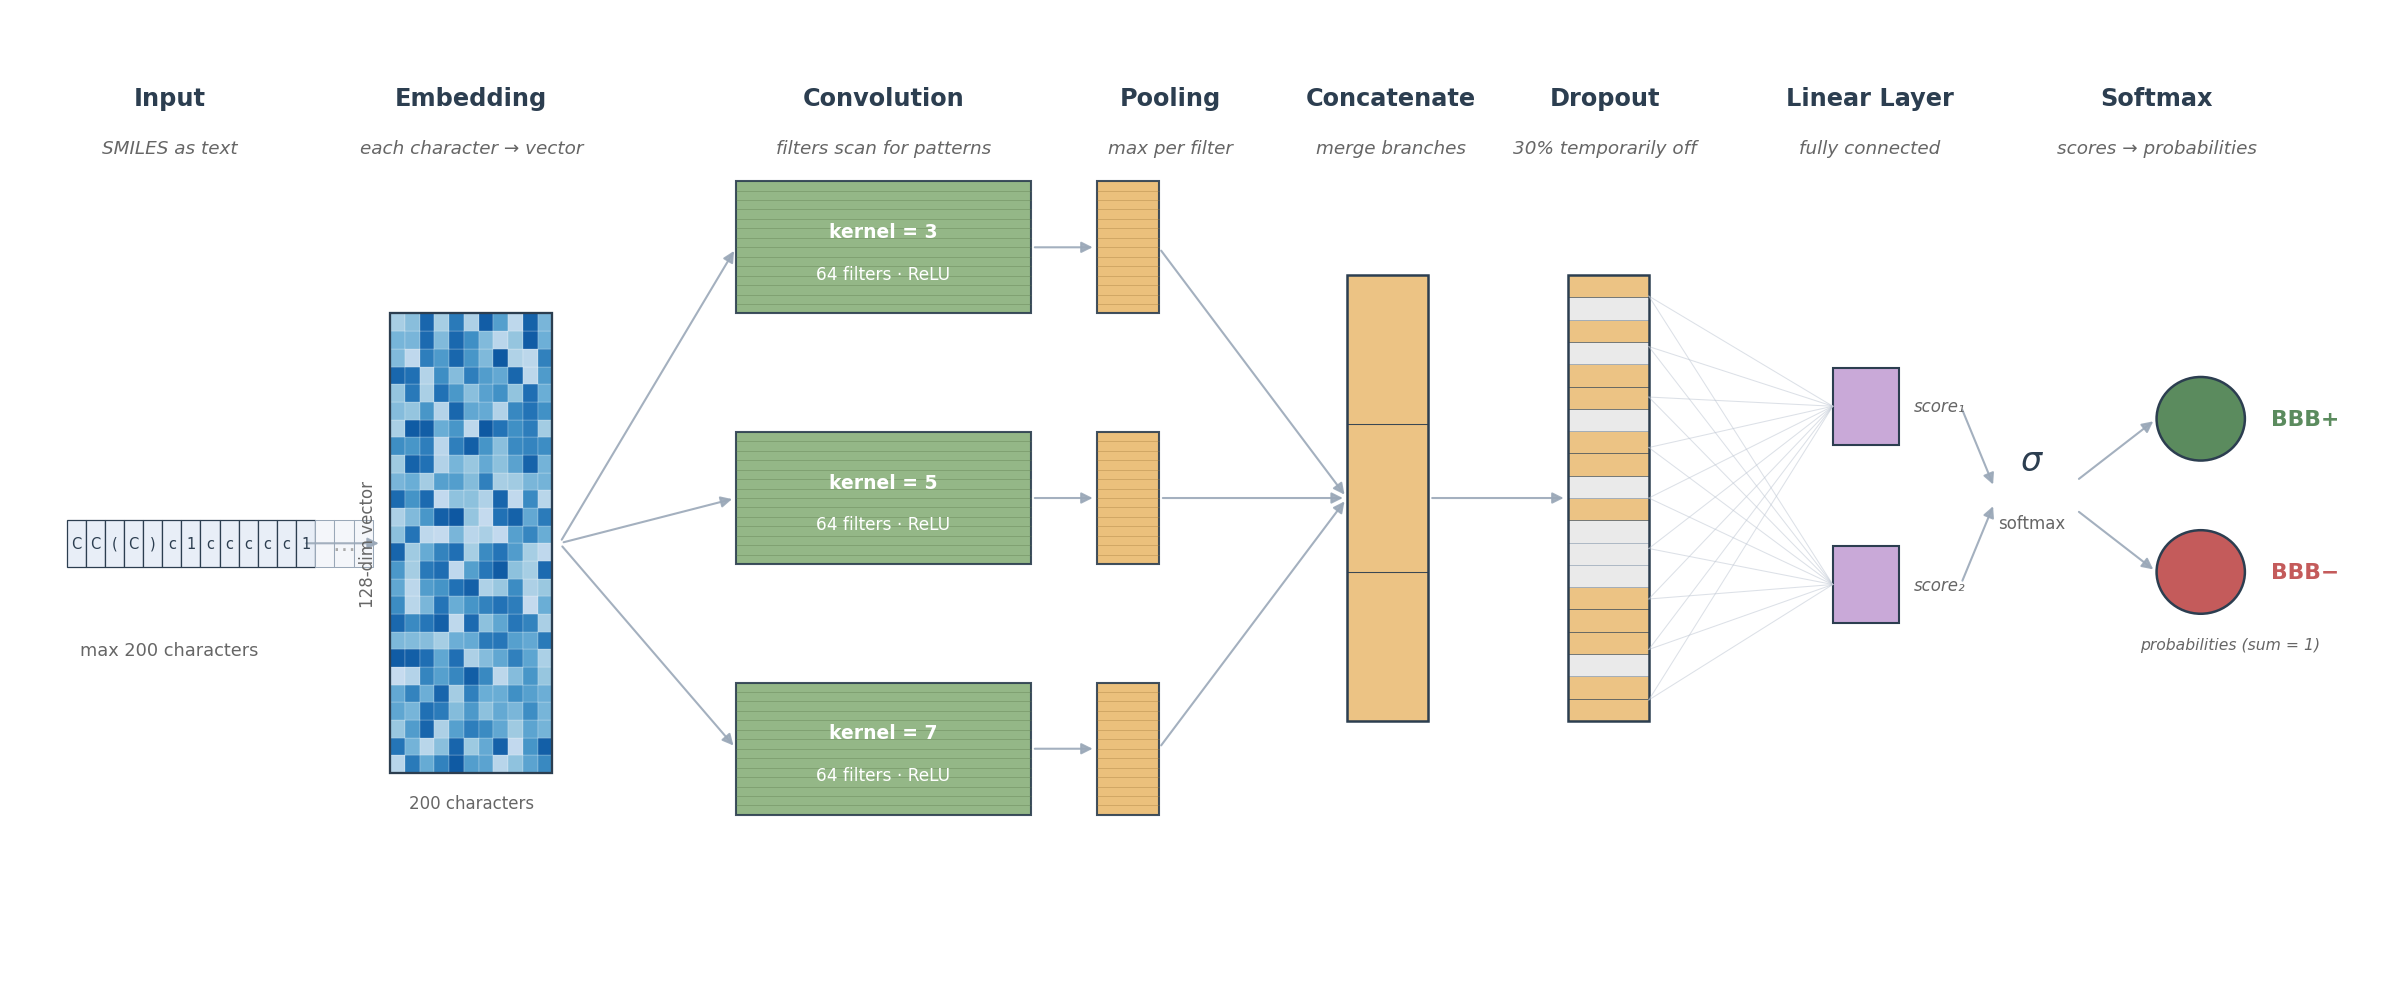

In [22]:
# === Visualization: SMILES-CNN architecture ===
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle, FancyArrowPatch, Circle
import numpy as np

plt.rcParams.update({"font.family": "DejaVu Sans", "font.size": 10})

COL_INPUT      = "#E8EEF7"
COL_EMBED_CMAP = plt.cm.Blues
COL_CONV       = "#88B07A"; COL_CONV_DK = "#5a7a4c"
COL_POOL       = "#E9B96E"; COL_POOL_DK = "#a07a3a"
COL_LOGIT      = "#C9A9D8"
COL_OUT_POS    = "#5B8B5E"; COL_OUT_NEG = "#C45B5B"
EDGE           = "#2c3e50"; EDGE_LIGHT  = "#9aa8b8"
TEXT_DIM       = "#666"

fig, ax = plt.subplots(figsize=(16, 6.8), dpi=150)
ax.set_xlim(0, 16); ax.set_ylim(0, 7); ax.axis("off")

def arrow(x1, y1, x2, y2, color=EDGE_LIGHT, lw=1.0):
    ax.add_patch(FancyArrowPatch((x1, y1), (x2, y2),
        arrowstyle="-|>", mutation_scale=11, linewidth=lw, color=color, alpha=0.9))

title_y, sub_y = 6.35, 6.0

# 1. Input
ax.text(1.05, title_y, "Input", ha="center", fontsize=11.5, fontweight="bold", color=EDGE)
ax.text(1.05, sub_y, "SMILES as text", ha="center", fontsize=8.8, color=TEXT_DIM, style="italic")
chars = ['C','C','(','C',')','c','1','c','c','c','c','c','1']
cell_w, cell_h, start_x, in_cy = 0.13, 0.34, 0.35, 3.2
for i, c in enumerate(chars):
    ax.add_patch(Rectangle((start_x + i*cell_w, in_cy - cell_h/2), cell_w, cell_h,
                            facecolor=COL_INPUT, edgecolor=EDGE, linewidth=0.6))
    ax.text(start_x + i*cell_w + cell_w/2, in_cy, c,
            ha="center", va="center", fontsize=7, color=EDGE)
for i in range(len(chars), len(chars) + 3):
    ax.add_patch(Rectangle((start_x + i*cell_w, in_cy - cell_h/2), cell_w, cell_h,
                            facecolor="#F4F6FA", edgecolor=EDGE_LIGHT, linewidth=0.5))
ax.text(start_x + (len(chars)+1.5)*cell_w, in_cy, "…",
        ha="center", va="center", fontsize=11, color="#aaa")
ax.text(1.05, 2.4, "max 200 characters", ha="center", fontsize=8.5, color=TEXT_DIM)

# 2. Embedding
ax.text(3.1, title_y, "Embedding", ha="center", fontsize=11.5, fontweight="bold", color=EDGE)
ax.text(3.1, sub_y, "each character → vector",
        ha="center", fontsize=8.8, color=TEXT_DIM, style="italic")
emb_x, emb_y, emb_w, emb_h = 2.55, 1.55, 1.1, 3.3
n_cols, n_rows = 11, 26
cs_w, cs_h = emb_w/n_cols, emb_h/n_rows
np.random.seed(7)
intens = 0.25 + 0.6*np.random.rand(n_rows, n_cols)
for r in range(n_rows):
    for c in range(n_cols):
        ax.add_patch(Rectangle((emb_x + c*cs_w, emb_y + r*cs_h), cs_w, cs_h,
                                facecolor=COL_EMBED_CMAP(intens[r, c]),
                                edgecolor="white", linewidth=0.1))
ax.add_patch(Rectangle((emb_x, emb_y), emb_w, emb_h,
                        facecolor="none", edgecolor=EDGE, linewidth=1.1))
ax.text(emb_x + emb_w/2, emb_y - 0.25, "200 characters", ha="center", fontsize=8, color=TEXT_DIM)
ax.text(emb_x - 0.15, emb_y + emb_h/2, "128-dim vector",
        ha="center", va="center", fontsize=8, color=TEXT_DIM, rotation=90)
arrow(1.95, in_cy, 2.5, in_cy)

# 3. Convolution
ax.text(5.9, title_y, "Convolution", ha="center", fontsize=11.5, fontweight="bold", color=EDGE)
ax.text(5.9, sub_y, "filters scan for patterns",
        ha="center", fontsize=8.8, color=TEXT_DIM, style="italic")
conv_x, conv_w, conv_h = 4.9, 2.0, 0.95
y_top, y_mid, y_bot = 4.85, 3.05, 1.25
for yp, k in zip([y_top, y_mid, y_bot], [3, 5, 7]):
    ax.add_patch(Rectangle((conv_x, yp), conv_w, conv_h,
                            facecolor=COL_CONV, edgecolor=EDGE, linewidth=1.0, alpha=0.9))
    for s in range(1, 14):
        ys = yp + s * conv_h / 14
        ax.plot([conv_x, conv_x + conv_w], [ys, ys], color=COL_CONV_DK, linewidth=0.3, alpha=0.55)
    ax.text(conv_x + conv_w/2, yp + conv_h*0.62, f"kernel = {k}",
            ha="center", va="center", fontsize=9, color="white", fontweight="bold")
    ax.text(conv_x + conv_w/2, yp + conv_h*0.30, "64 filters · ReLU",
            ha="center", va="center", fontsize=8.2, color="white")
for yp in [y_top, y_mid, y_bot]:
    arrow(3.7, in_cy, conv_x, yp + conv_h/2)

# 4. Pooling
ax.text(7.85, title_y, "Pooling", ha="center", fontsize=11.5, fontweight="bold", color=EDGE)
ax.text(7.85, sub_y, "max per filter",
        ha="center", fontsize=8.8, color=TEXT_DIM, style="italic")
pool_x, pool_w = 7.35, 0.42
for yp in [y_top, y_mid, y_bot]:
    ax.add_patch(Rectangle((pool_x, yp), pool_w, conv_h,
                            facecolor=COL_POOL, edgecolor=EDGE, linewidth=1.0, alpha=0.9))
    for s in range(1, 14):
        ys = yp + s * conv_h / 14
        ax.plot([pool_x, pool_x + pool_w], [ys, ys],
                color=COL_POOL_DK, linewidth=0.3, alpha=0.55)
    arrow(conv_x + conv_w, yp + conv_h/2, pool_x, yp + conv_h/2)

# 5. Concatenate
ax.text(9.35, title_y, "Concatenate", ha="center", fontsize=11.5, fontweight="bold", color=EDGE)
ax.text(9.35, sub_y, "merge branches",
        ha="center", fontsize=8.8, color=TEXT_DIM, style="italic")
cat_x, cat_w, cat_h = 9.05, 0.55, 3.2
cat_y = (y_top + y_bot + conv_h)/2 - cat_h/2
for i in range(3):
    ax.add_patch(Rectangle((cat_x, cat_y + i * cat_h/3), cat_w, cat_h/3,
                            facecolor=COL_POOL, edgecolor=EDGE, linewidth=0.5, alpha=0.85))
ax.add_patch(Rectangle((cat_x, cat_y), cat_w, cat_h,
                        facecolor="none", edgecolor=EDGE, linewidth=1.2))
for yp in [y_top, y_mid, y_bot]:
    arrow(pool_x + pool_w, yp + conv_h/2, cat_x, cat_y + cat_h/2)

# 6. Dropout
ax.text(10.8, title_y, "Dropout", ha="center", fontsize=11.5, fontweight="bold", color=EDGE)
ax.text(10.8, sub_y, "30% temporarily off",
        ha="center", fontsize=8.8, color=TEXT_DIM, style="italic")
drop_x, drop_w, drop_h, drop_y = 10.55, 0.55, cat_h, cat_y
n_dots = 20
dot_h = drop_h / n_dots
np.random.seed(3)
off = np.random.rand(n_dots) < 0.30
for i in range(n_dots):
    sy = drop_y + i*dot_h
    color = "#EAEAEA" if off[i] else COL_POOL
    edge_c = EDGE_LIGHT if off[i] else EDGE
    alpha = 1.0 if off[i] else 0.85
    ax.add_patch(Rectangle((drop_x, sy), drop_w, dot_h,
                            facecolor=color, edgecolor=edge_c, linewidth=0.3, alpha=alpha))
ax.add_patch(Rectangle((drop_x, drop_y), drop_w, drop_h,
                        facecolor="none", edgecolor=EDGE, linewidth=1.2))
arrow(cat_x + cat_w, cat_y + cat_h/2, drop_x, drop_y + drop_h/2)

# 7. Linear Layer (FC → 2 logits)
ax.text(12.6, title_y, "Linear Layer", ha="center", fontsize=11.5, fontweight="bold", color=EDGE)
ax.text(12.6, sub_y, "fully connected",
        ha="center", fontsize=8.8, color=TEXT_DIM, style="italic")
logit_x, logit_w, logit_h = 12.35, 0.45, 0.55
logit_y_t = drop_y + drop_h * 0.62
logit_y_b = drop_y + drop_h * 0.22
for ly in [logit_y_t, logit_y_b]:
    ax.add_patch(Rectangle((logit_x, ly), logit_w, logit_h,
                            facecolor=COL_LOGIT, edgecolor=EDGE, linewidth=1.0))
ax.text(logit_x + logit_w + 0.1, logit_y_t + logit_h/2, "score₁",
        va="center", fontsize=8, color=TEXT_DIM, style="italic")
ax.text(logit_x + logit_w + 0.1, logit_y_b + logit_h/2, "score₂",
        va="center", fontsize=8, color=TEXT_DIM, style="italic")
sample_ys = np.linspace(drop_y + 0.15, drop_y + drop_h - 0.15, 9)
for ly in sample_ys:
    for oy in [logit_y_t + logit_h/2, logit_y_b + logit_h/2]:
        ax.plot([drop_x + drop_w, logit_x], [ly, oy],
                color="#c0c8d4", linewidth=0.5, alpha=0.55, zorder=1)

# 8. Softmax + outputs
ax.text(14.55, title_y, "Softmax", ha="center", fontsize=11.5, fontweight="bold", color=EDGE)
ax.text(14.55, sub_y, "scores → probabilities",
        ha="center", fontsize=8.8, color=TEXT_DIM, style="italic")
sm_x, sm_w = 13.45, 0.5
sm_y_center = (logit_y_t + logit_y_b + logit_h) / 2
ax.text(sm_x + sm_w/2, sm_y_center + 0.25, "σ",
        ha="center", va="center", fontsize=16, color=EDGE, style="italic")
ax.text(sm_x + sm_w/2, sm_y_center - 0.2, "softmax",
        ha="center", va="center", fontsize=8, color=TEXT_DIM)
arrow(logit_x + logit_w + 0.42, logit_y_t + logit_h/2, sm_x, sm_y_center + 0.05)
arrow(logit_x + logit_w + 0.42, logit_y_b + logit_h/2, sm_x, sm_y_center - 0.05)

out_x, out_r = 14.85, 0.3
out_y_t = sm_y_center + 0.55
out_y_b = sm_y_center - 0.55
ax.add_patch(Circle((out_x, out_y_t), out_r,
                     facecolor=COL_OUT_POS, edgecolor=EDGE, linewidth=1.2, zorder=3))
ax.add_patch(Circle((out_x, out_y_b), out_r,
                     facecolor=COL_OUT_NEG, edgecolor=EDGE, linewidth=1.2, zorder=3))
arrow(sm_x + sm_w + 0.05, sm_y_center + 0.1, out_x - out_r, out_y_t)
arrow(sm_x + sm_w + 0.05, sm_y_center - 0.1, out_x - out_r, out_y_b)
ax.text(out_x + out_r + 0.18, out_y_t, "BBB+", va="center",
        fontsize=10.5, fontweight="bold", color=COL_OUT_POS)
ax.text(out_x + out_r + 0.18, out_y_b, "BBB−", va="center",
        fontsize=10.5, fontweight="bold", color=COL_OUT_NEG)
ax.text(out_x + 0.2, out_y_b - 0.55, "probabilities (sum = 1)",
        ha="center", fontsize=7.5, color=TEXT_DIM, style="italic")

plt.tight_layout()
plt.savefig("cnn_architecture.png", dpi=300, bbox_inches="tight", facecolor="white")
plt.show()

Generate a card-style summary of the training configuration: loss function, optimizer, training loop, validation strategy, and prediction method. For use in the presentation.

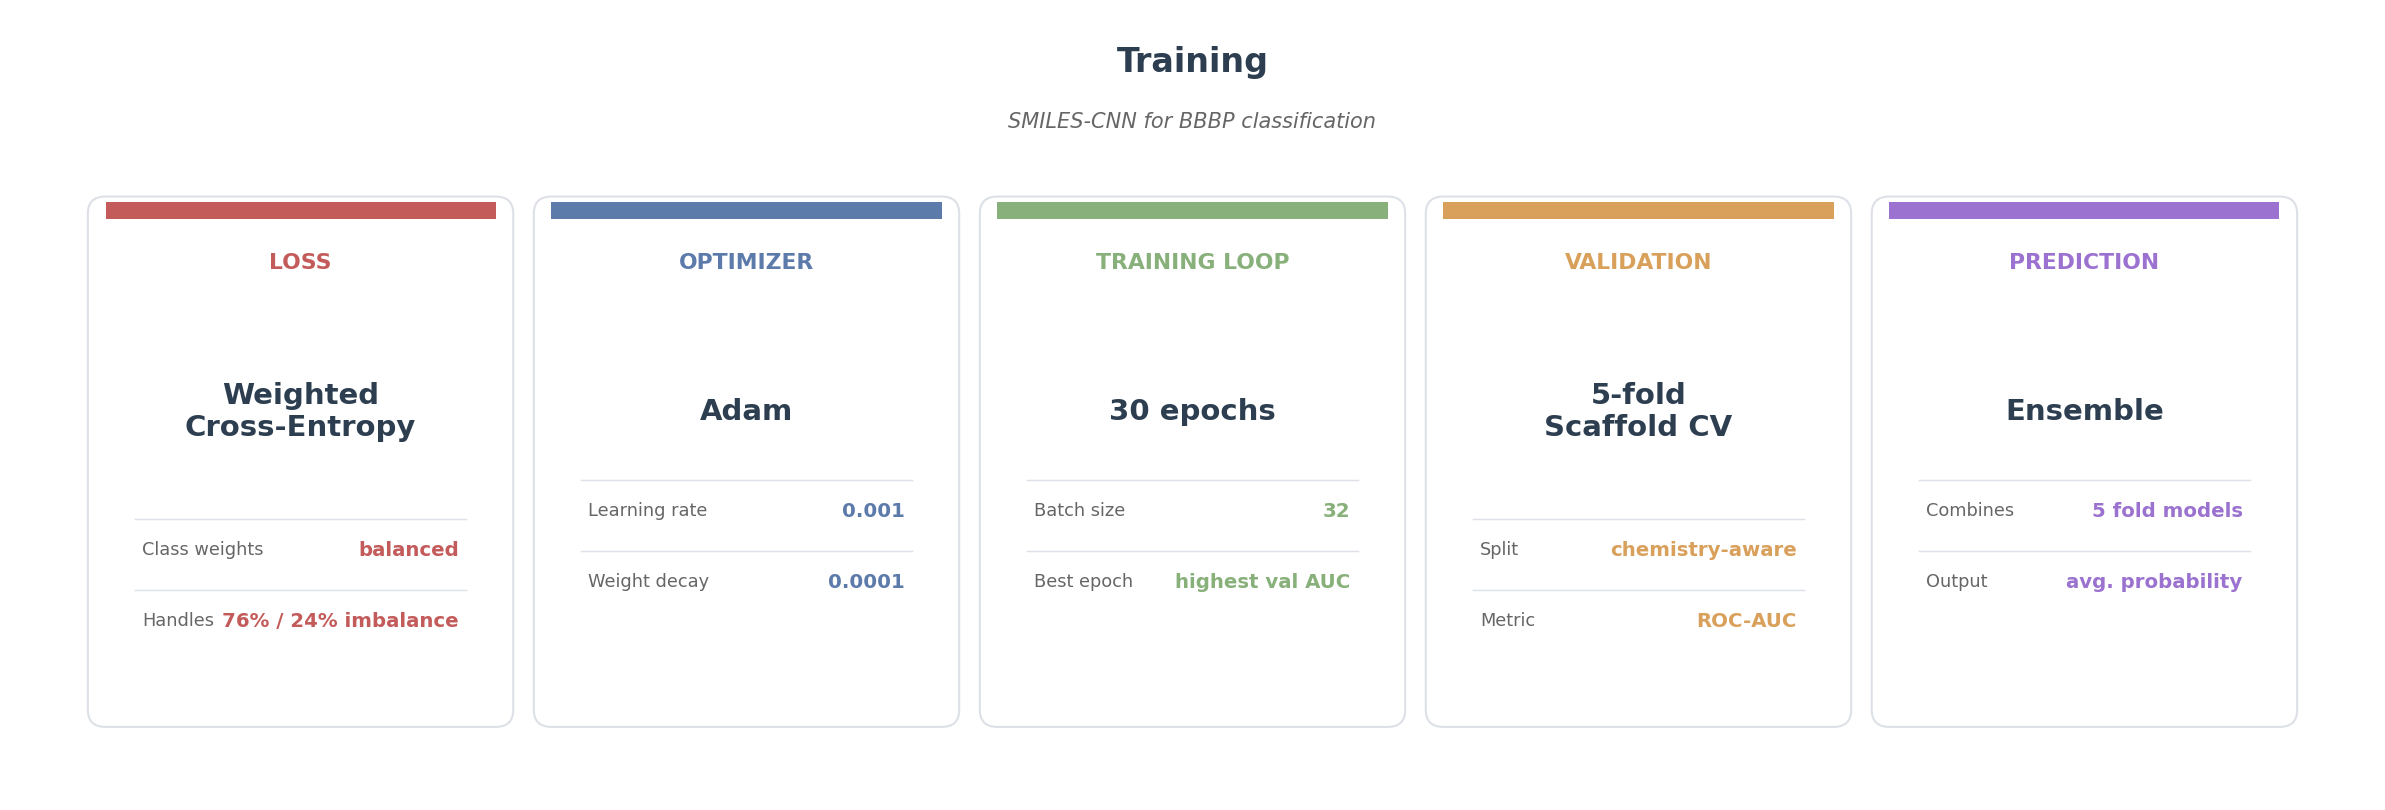

In [24]:
# === Visualization: Training configuration ===
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle, FancyBboxPatch

plt.rcParams.update({"font.family": "DejaVu Sans", "font.size": 10})

EDGE       = "#2c3e50"
TEXT_DIM   = "#666"
LINE_LIGHT = "#dde1e7"

CARDS = [
    ("LOSS", "#C45B5B",
     "Weighted\nCross-Entropy",
     [("Class weights", "balanced"),
      ("Handles", "76% / 24% imbalance")]),
    ("OPTIMIZER", "#5C7AAA",
     "Adam",
     [("Learning rate", "0.001"),
      ("Weight decay", "0.0001")]),
    ("TRAINING LOOP", "#88B07A",
     "30 epochs",
     [("Batch size", "32"),
      ("Best epoch", "highest val AUC")]),
    ("VALIDATION", "#D9A05B",
     "5-fold\nScaffold CV",
     [("Split", "chemistry-aware"),
      ("Metric", "ROC-AUC")]),
    ("PREDICTION", "#9B72CF",
     "Ensemble",
     [("Combines", "5 fold models"),
      ("Output", "avg. probability")]),
]

fig, ax = plt.subplots(figsize=(16, 5.5), dpi=150)
ax.set_xlim(0, 16); ax.set_ylim(0, 5.5); ax.axis("off")

ax.text(8, 5.1, "Training",
        ha="center", fontsize=16, fontweight="bold", color=EDGE)
ax.text(8, 4.7, "SMILES-CNN for BBBP classification",
        ha="center", fontsize=10, style="italic", color=TEXT_DIM)

n = len(CARDS)
card_w, gap = 2.85, 0.18
total_w = n * card_w + (n - 1) * gap
start_x = (16 - total_w) / 2
card_y, card_h = 0.5, 3.7

for i, (title, dark, headline, details) in enumerate(CARDS):
    x = start_x + i * (card_w + gap)

    # Card body
    ax.add_patch(FancyBboxPatch(
        (x, card_y), card_w, card_h,
        boxstyle="round,pad=0.02,rounding_size=0.12",
        facecolor="white", edgecolor=LINE_LIGHT, linewidth=1.0))

    # Color accent band at top
    band_h = 0.12
    ax.add_patch(Rectangle(
        (x + 0.1, card_y + card_h - band_h - 0.02), card_w - 0.2, band_h,
        facecolor=dark, edgecolor="none"))

    # Title
    ax.text(x + card_w/2, card_y + card_h - 0.45, title,
            ha="center", va="center", fontsize=10.5, fontweight="bold", color=dark)

    # Headline value
    headline_y = card_y + card_h - 1.5
    ax.text(x + card_w/2, headline_y, headline,
            ha="center", va="center", fontsize=14, fontweight="bold", color=EDGE)

    # Details
    n_lines = headline.count("\n") + 1
    hl_box_h = 0.55 * n_lines + 0.25
    detail_top = headline_y - hl_box_h/2 - 0.3
    for j, (label, value) in enumerate(details):
        dy = detail_top - j * 0.5
        ax.plot([x + 0.3, x + card_w - 0.3], [dy + 0.22, dy + 0.22],
                color=LINE_LIGHT, linewidth=0.7)
        ax.text(x + 0.35, dy, label, ha="left", va="center",
                fontsize=8.5, color=TEXT_DIM)
        ax.text(x + card_w - 0.35, dy, value, ha="right", va="center",
                fontsize=9.5, fontweight="bold", color=dark)

plt.tight_layout()
plt.savefig("training_config.png", dpi=300, bbox_inches="tight", facecolor="white")
plt.show()

Generate the final test set dashboard: the three headline metrics (accuracy, ROC-AUC, macro F1) and a confusion matrix with the TN/FP/FN/TP breakdown. For use in the presentation.

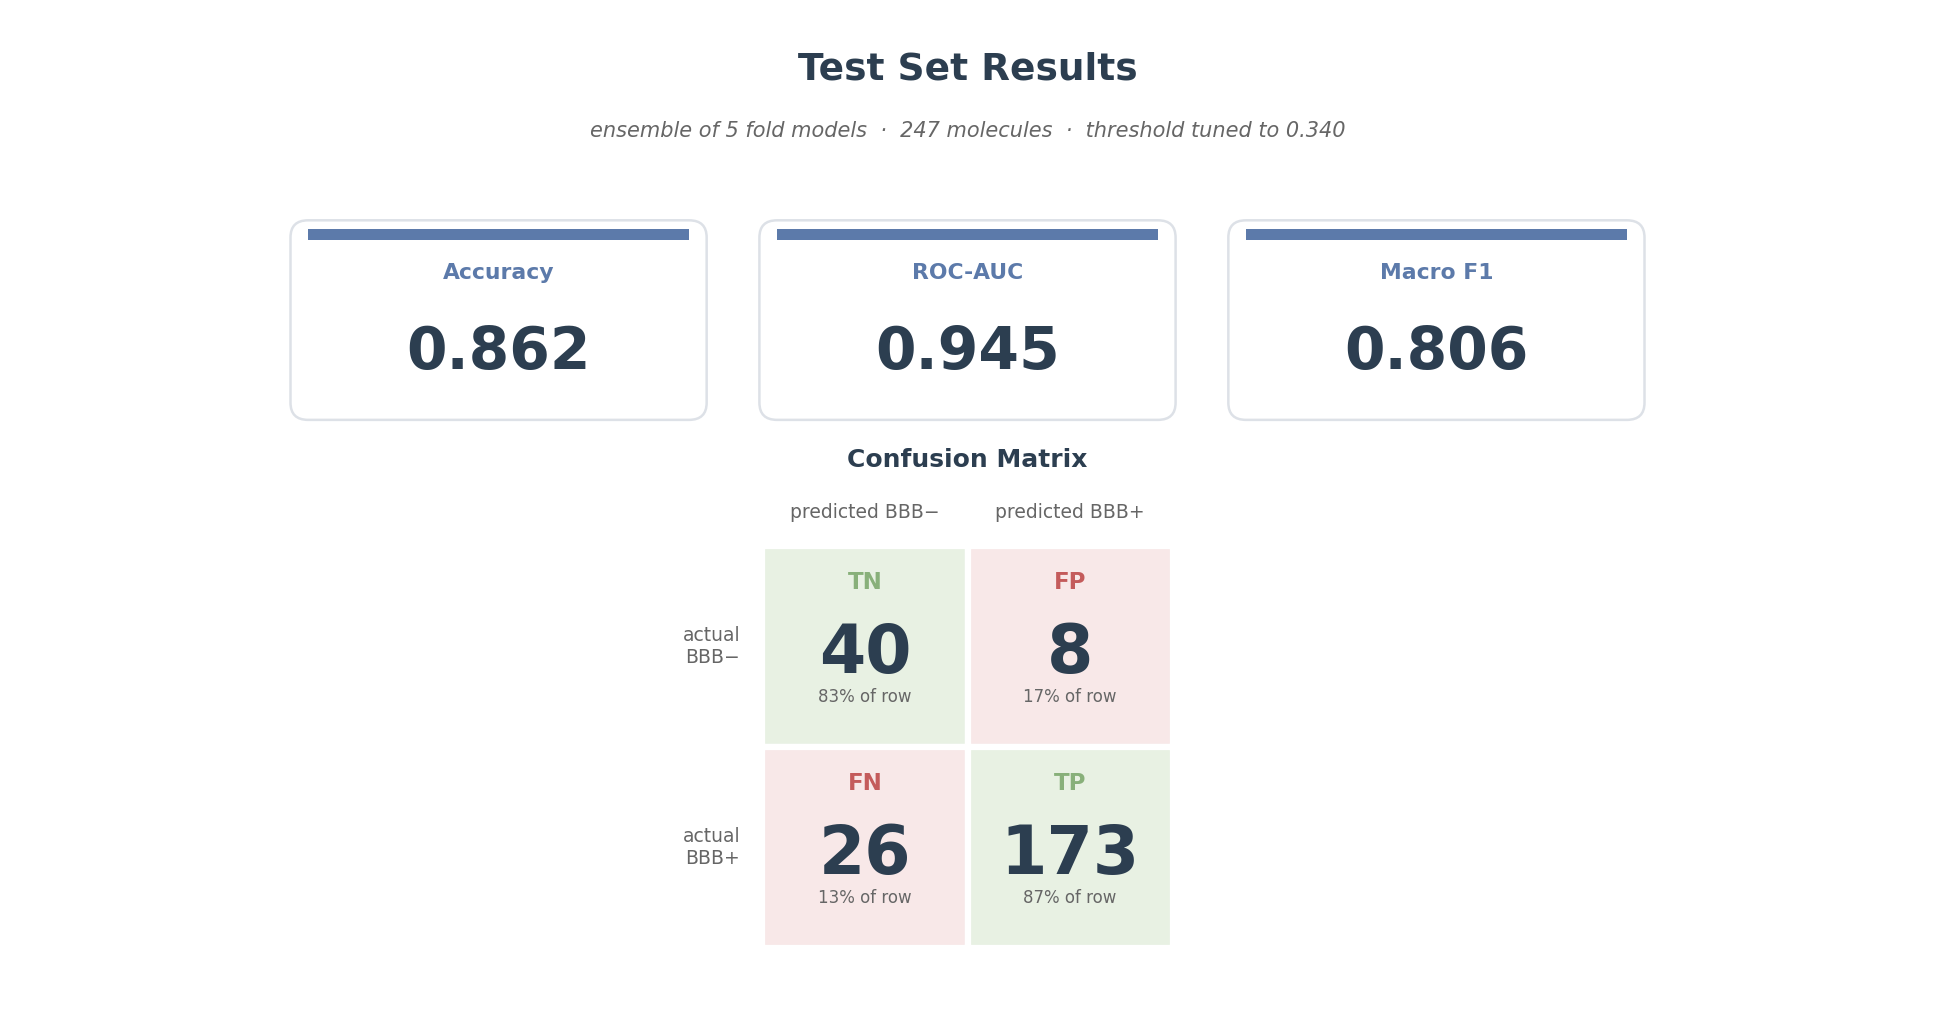

In [27]:
# === Visualization: Test set results summary ===
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle, FancyBboxPatch
from sklearn.metrics import (confusion_matrix, accuracy_score,
                              roc_auc_score, f1_score)

plt.rcParams.update({"font.family": "DejaVu Sans", "font.size": 10})

EDGE         = "#2c3e50"
TEXT_DIM     = "#666"
LINE_LIGHT   = "#dde1e7"
COL_METRIC   = "#5C7AAA"
COL_CORRECT  = "#88B07A"
COL_WRONG    = "#C45B5B"
COL_BG_GREEN = "#E8F1E3"
COL_BG_RED   = "#F8E8E8"

# Compute everything using existing notebook variables
y_pred = (mean_probs > best_t).astype(int)
cm = confusion_matrix(y_true, y_pred)
tn, fp, fn, tp = cm.ravel()
n_total = len(y_true)

acc     = accuracy_score(y_true, y_pred)
roc_auc = roc_auc_score(y_true, mean_probs)
mf1     = f1_score(y_true, y_pred, average="macro")

fig, ax = plt.subplots(figsize=(13, 7), dpi=150)
ax.set_xlim(0, 13); ax.set_ylim(0, 7); ax.axis("off")

# Title
ax.text(6.5, 6.55, "Test Set Results",
        ha="center", fontsize=18, fontweight="bold", color=EDGE)
ax.text(6.5, 6.15,
        f"ensemble of 5 fold models  ·  {n_total} molecules  ·  "
        f"threshold tuned to {best_t:.3f}",
        ha="center", fontsize=10, style="italic", color=TEXT_DIM)

# --- 3 metric cards ---
metrics = [("Accuracy", acc), ("ROC-AUC", roc_auc), ("Macro F1", mf1)]
card_w, card_h, gap = 2.8, 1.35, 0.4
total_w = 3 * card_w + 2 * gap
start_x = (13 - total_w) / 2
card_y = 4.2

for i, (label, value) in enumerate(metrics):
    x = start_x + i * (card_w + gap)
    ax.add_patch(FancyBboxPatch(
        (x, card_y), card_w, card_h,
        boxstyle="round,pad=0.02,rounding_size=0.12",
        facecolor="white", edgecolor=LINE_LIGHT, linewidth=1.2))
    ax.add_patch(Rectangle(
        (x + 0.1, card_y + card_h - 0.12), card_w - 0.2, 0.08,
        facecolor=COL_METRIC, edgecolor="none"))
    ax.text(x + card_w/2, card_y + card_h - 0.35, label,
            ha="center", va="center", fontsize=10.5,
            fontweight="bold", color=COL_METRIC)
    ax.text(x + card_w/2, card_y + 0.45, f"{value:.3f}",
            ha="center", va="center", fontsize=28,
            fontweight="bold", color=EDGE)

# --- Confusion matrix ---
cm_size = 2.8
cm_cell = cm_size / 2
cm_x = (13 - cm_size) / 2
cm_y = 0.5

ax.text(cm_x + cm_size/2, 3.85, "Confusion Matrix",
        ha="center", fontsize=12, fontweight="bold", color=EDGE)
ax.text(cm_x + cm_cell/2,     3.50, "predicted BBB−",
        ha="center", fontsize=9, color=TEXT_DIM)
ax.text(cm_x + cm_cell * 1.5, 3.50, "predicted BBB+",
        ha="center", fontsize=9, color=TEXT_DIM)
ax.text(cm_x - 0.15, cm_y + cm_cell * 1.5, "actual\nBBB−",
        ha="right", va="center", fontsize=9, color=TEXT_DIM)
ax.text(cm_x - 0.15, cm_y + cm_cell / 2, "actual\nBBB+",
        ha="right", va="center", fontsize=9, color=TEXT_DIM)

# Cells: (col, row_from_bottom, count, label, accent, bg)
cells = [
    (0, 1, tn, "TN", COL_CORRECT, COL_BG_GREEN),
    (1, 1, fp, "FP", COL_WRONG,   COL_BG_RED),
    (0, 0, fn, "FN", COL_WRONG,   COL_BG_RED),
    (1, 0, tp, "TP", COL_CORRECT, COL_BG_GREEN),
]
for col, row, count, label, accent, bg in cells:
    x = cm_x + col * cm_cell
    y = cm_y + row * cm_cell
    ax.add_patch(Rectangle((x, y), cm_cell, cm_cell,
                            facecolor=bg, edgecolor="white", linewidth=3))
    ax.text(x + cm_cell/2, y + cm_cell - 0.25, label,
            ha="center", va="center", fontsize=11,
            fontweight="bold", color=accent)
    ax.text(x + cm_cell/2, y + cm_cell/2 - 0.05, f"{count}",
            ha="center", va="center", fontsize=32,
            fontweight="bold", color=EDGE)
    row_total = (tn + fp) if row == 1 else (fn + tp)
    pct = count / row_total * 100 if row_total else 0
    ax.text(x + cm_cell/2, y + 0.35, f"{pct:.0f}% of row",
            ha="center", va="center", fontsize=8, color=TEXT_DIM)

plt.tight_layout()
plt.savefig("eval_summary.png", dpi=300, bbox_inches="tight", facecolor="white")
plt.show()